In [1]:
%env CUDA_VISIBLE_DEVICES = 7

env: CUDA_VISIBLE_DEVICES=7


In [6]:
from fetch_dataset_and_processing import find_train_val_files, find_test_files, ImageNet
from train_loop import train
from inference import predict, predict_one_sample, make_predictions
from visualizing import imshow, plot_train_set, plot_results

from ResNet_models.resnet18_cnn import ResBlock, ResNet18
from ResNet_models.resnet_new import ResNet50, ResNext 

import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
import os
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

In [4]:
device = 'cuda:0'

In [41]:
train_val_files, train_val_labels = find_train_val_files()
test_files, test_labels = find_test_files()

In [42]:
len(train_val_files), len(test_files)

(9103, 3791)

In [43]:
train_set, val_set, tr_labels, val_labels = train_test_split(train_val_files, train_val_labels, test_size=0.2, \
                                          stratify=train_val_labels)

In [44]:
train_dataset = ImageNet(train_set, tr_labels, 'train')
val_dataset = ImageNet(val_set, val_labels, 'val')
test_dataset = ImageNet(test_files, test_labels, 'test')

In [45]:
batch_size = 8
train_loader = DataLoader(train_dataset, batch_size=batch_size)
val_loader = DataLoader(val_dataset, batch_size=batch_size)

In [ ]:
resnext = ResNext().to(device)
resnext

In [6]:
resnext = ResNext(version='D')

In [51]:
epochs = 20
opt = torch.optim.Adam(resnext.parameters(), lr=1e-4)
loss_fn = nn.CrossEntropyLoss()
path = 'ResNet_exp/ResNext.pth'
name = 'ResNet_exp/ResNext'

In [52]:
losses, metrics = train(resnext, opt, loss_fn, epochs, train_loader, val_loader, name, path)

Epoch 0/19:


train iter:: 100%|██████████| 911/911 [01:26<00:00, 10.53it/s]


train Loss: 1.8901
train Accuracy: 0.3609


val iter:: 100%|██████████| 228/228 [00:10<00:00, 21.13it/s]


val Loss: 2.1322
val Accuracy: 0.3877
Epoch 1/19:


...

val Loss: 1.2065
val Accuracy: 0.6870
Epoch 19/19:


train iter:: 100%|██████████| 911/911 [01:18<00:00, 11.59it/s]


train Loss: 0.0315
train Accuracy: 0.9999


val iter:: 100%|██████████| 228/228 [00:08<00:00, 27.38it/s]


val Loss: 1.2065
val Accuracy: 0.6870


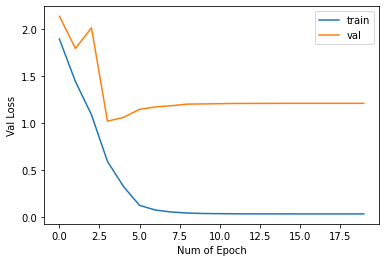

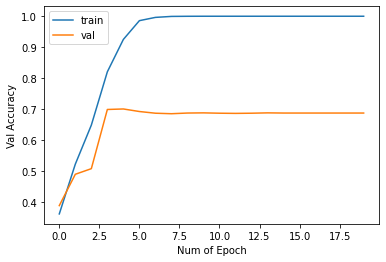

In [53]:
plt.plot(losses['train'], label='train')
plt.plot(losses['val'], label='val')
plt.legend()
plt.ylabel('Val Loss')
plt.xlabel('Num of Epoch')
plt.show()


plt.plot(metrics['train'], label='train')
plt.plot(metrics['val'], label='val')
plt.ylabel('Val Accuracy')
plt.xlabel('Num of Epoch')
plt.legend()
plt.show()